In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import openpyxl

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("dataset/Customer-Purchase-History.xlsx")
df.head(10)

,CustomerID,Product,PurchaseDate,Quantity,UnitPrice,CustomerName,ProductCategory,PaymentMethod,ReviewRating,TotalPrice
0,C5361,Phone,2024-03-05,8,618.83,Customer C5361,Office Supplies,Cash,1,4950.64
1,C6231,Laptop,2025-06-21,7,366.22,Customer C6231,Electronics,Debit Card,3,2563.54
2,C7704,Chair,2023-06-25,5,634.51,Customer C7704,Office Supplies,Credit Card,4,3172.55
3,C2923,Printer,2023-09-30,3,508.63,Customer C2923,Office Supplies,Gift Card,1,1525.89
4,C4847,Monitor,2023-04-03,4,452.06,Customer C4847,Electronics,Credit Card,2,1808.24
5,C7317,Chair,2023-04-11,3,209.79,Customer C7317,Office Supplies,Gift Card,1,629.37
6,C5076,Desk,2024-06-19,3,88.74,Customer C5076,Office Supplies,Debit Card,3,266.22
7,C5181,Chair,2023-08-16,8,273.92,Customer C5181,Furniture,Credit Card,2,2191.36
8,C9564,Monitor,2023-02-11,6,718.79,Customer C9564,Electronics,Gift Card,3,4312.74
9,C7521,Tablet,2025-06-14,7,100.37,Customer C7521,Office Supplies,Debit Card,4,702.59


In [23]:
df.columns

Index(['CustomerID', 'Product', 'PurchaseDate', 'Quantity', 'UnitPrice',
       'CustomerName', 'ProductCategory', 'PaymentMethod', 'ReviewRating',
       'TotalPrice'],
      dtype='object')

In [6]:
df.shape

(1800, 10)

In [7]:
df.isnull().sum()

CustomerID         0
Product            0
PurchaseDate       0
Quantity           0
UnitPrice          0
CustomerName       0
ProductCategory    0
PaymentMethod      0
ReviewRating       0
TotalPrice         0
dtype: int64

In [14]:
df["Product"].value_counts()

Product
Laptop     280
Tablet     278
Desk       256
Monitor    254
Chair      253
Phone      246
Printer    233
Name: count, dtype: int64

In [49]:
df["ProductCategory"].value_counts()

ProductCategory
Electronics        606
Office Supplies    597
Furniture          597
Name: count, dtype: int64

# Sales Performance & Revenue

##### 1- Which product categories and individual products are the primary drivers of revenue, and how concentrated is revenue among top-performing products?

<p><b>Strategic Value:</b> Identifies the products/categories that deserve greater inventory, marketing, and management attention while revealing dependency on a small number of products.</p>

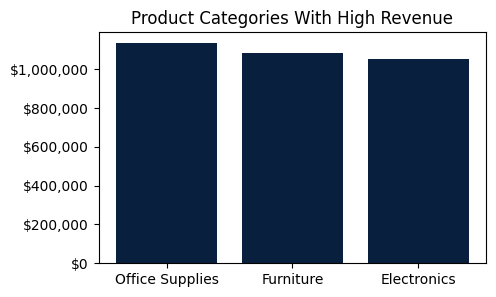

In [75]:
product_category = df.groupby(["ProductCategory"],as_index=False)["TotalPrice"].sum()
product_category = product_category.sort_values(by="TotalPrice",ascending=False).reset_index(drop=True)
# product_category["RevenueShare"] = (product_category["TotalPrice"] / np.sum(product_category["TotalPrice"]))*100

plt.figure(figsize=(5,3))
plt.bar(product_category["ProductCategory"],product_category["TotalPrice"],color="#08203E")
plt.title("Product Categories With High Revenue")
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${x:,.0f}'))

plt.show()

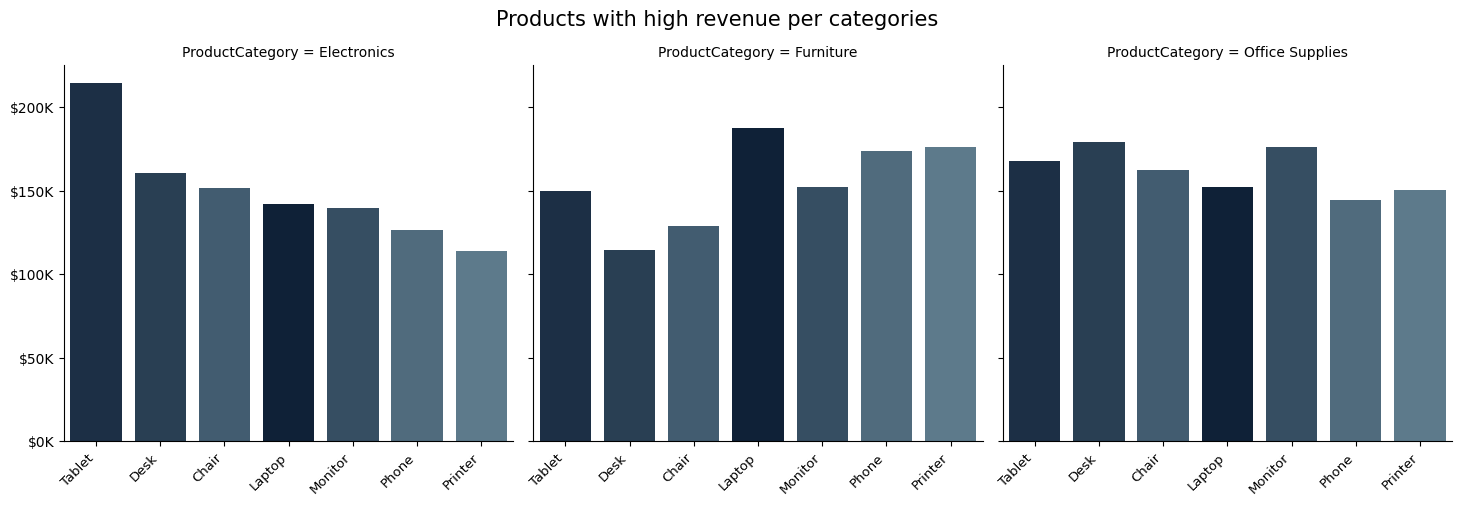

In [77]:
product = df.groupby(["ProductCategory","Product"], as_index=False)["TotalPrice"].sum()
product = product.sort_values(by=["ProductCategory","TotalPrice"], ascending=[True,False]).reset_index(drop=True)

colors = {
    "Laptop" : "#08203E",
    "Tablet" : "#152F4C",
    "Desk" : "#223F5A",
    "Monitor" : "#2F4E69",
    "Chair" : "#3B5D77",
    "Phone" : "#486D85",
    "Printer" : "#557C93"
}
ax = sns.catplot(data=product, kind="bar", x="Product",
                 y="TotalPrice", col="ProductCategory",
                 palette=colors)

for axis in ax.axes.flat:
    axis.yaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f'${x/1000:.0f}K')
    )

ax.set_xlabels("")
ax.set_ylabels("")
ax.set_xticklabels(fontsize=9.5, rotation=45, horizontalalignment='right')
ax.fig.subplots_adjust(top=0.87)
ax.fig.suptitle('Products with high revenue per categories', fontsize=15)

plt.savefig('plots/Sales Performance & Revenue/Question 01/Products with high revenue per categories.png')

plt.show()

##### 2- How has sales revenue and sales volume evolved over time, and are there statistically meaningful periods of growth or decline?

<p><b>Strategic Value:</b> Reveals business growth patterns, seasonality, demand changes, and periods requiring investigation or intervention.</p>

In [81]:
print(df["PurchaseDate"].max())
print(df["PurchaseDate"].min())
print(df["PurchaseDate"].max() - df["PurchaseDate"].min())

2025-06-30 00:00:00
2023-01-01 00:00:00
911 days 00:00:00


##### 3- Which products generate high revenue but low sales volume, and which generate high volume but relatively low revenue?

<p><b>Strategic Value:</b> Helps distinguish premium/high-value products from volume-driven products and supports differentiated pricing and inventory strategies.</p>

In [78]:
# Sales Performance & Revenue
product_category.to_excel("export-data/Sales Performance & Revenue/Question 01/product_category_revenue.xlsx",index=False)
product.to_excel("export-data/Sales Performance & Revenue/Question 01/product_revenue.xlsx",index=False)